## Insurance Claims

Objective: To explain factors that are associated to car insurance claims due to accidents or other events leading to car damage

Response Variable: The number of car insurance claims per policyholder.
* Holder: numbers of policyholders
* Claims: numbers of claims

Predicting Variable:
* District of residence of policyholder (1 to4): 4 is major cities.
* Classification of cars with levels <1 litre, 1.5-2 litre, >2 litre
* Age group of the policyholder: <25, 25-29, 30-35, >35

In [1]:
#Load Packages
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.stats import chi2, norm
from statsmodels.stats.outliers_influence import OLSInfluence
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod import families
from pathlib import Path
import statsmodels.formula.api as smf

import warnings
warnings.filterwarnings('ignore')



In [2]:
# Load data
project_root = Path.cwd().parent
data_file = project_root / "insurance_data.csv"
Insurance = pd.read_csv(data_file)
print(Insurance.head())


   District   Group    Age  Holders  Claims
0         1     <1l    <25      197      38
1         1     <1l  25-29      264      35
2         1     <1l  30-35      246      20
3         1     <1l    >35     1680     156
4         1  1-1.5l    <25      284      63


In [3]:
Insurance["ClaimRate"] = Insurance["Claims"]/ Insurance["Holders"]
Insurance

,District,Group,Age,Holders,Claims,ClaimRate
0,1,<1l,<25,197,38,0.192893
1,1,<1l,25-29,264,35,0.132576
2,1,<1l,30-35,246,20,0.081301
3,1,<1l,>35,1680,156,0.092857
4,1,1-1.5l,<25,284,63,0.221831
...,...,...,...,...,...,...
59,4,1.5-2l,>35,344,63,0.183140
60,4,>2l,<25,3,0,0.000000
61,4,>2l,25-29,16,6,0.375000
62,4,>2l,30-35,25,8,0.320000


In [4]:
Insurance.describe()

,District,Holders,Claims,ClaimRate
count,64.000000,64.000000,64.000000,64.000000
mean,2.500000,364.984375,49.234375,0.179971
std,1.126872,622.770601,71.162399,0.082046
min,1.000000,3.000000,0.000000,0.000000
25%,1.750000,46.750000,9.500000,0.128590
50%,2.500000,136.000000,22.000000,0.163768
75%,3.250000,327.500000,55.500000,0.209368
max,4.000000,3582.000000,400.000000,0.444444


## Exploratory Analysis

To visualize the relationship between the three categorical variables and the rate of claims per policyholder, we can use a side by side boxplot. The variable of interest is the rate of claims which is computed as the ratio between the number of claims and the number of policyholders. 

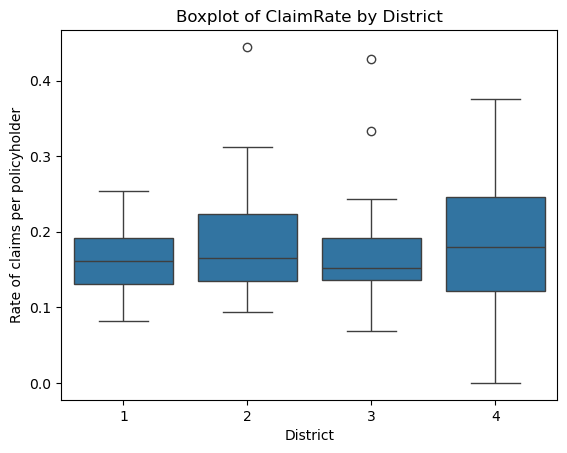

In [5]:
sns.boxplot(x=Insurance["District"], y=Insurance["ClaimRate"], data=Insurance)
plt.ylabel("Rate of claims per policyholder")
plt.title("Boxplot of ClaimRate by District")
plt.show()

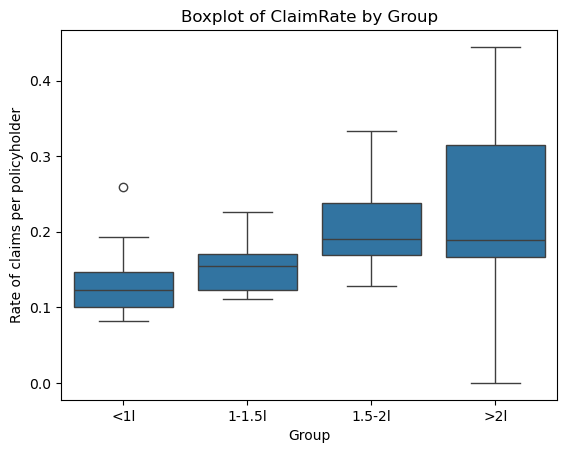

In [6]:
sns.boxplot(x=Insurance["Group"], y=Insurance["ClaimRate"], data=Insurance)
plt.ylabel("Rate of claims per policyholder")
plt.title("Boxplot of ClaimRate by Group")
plt.show()

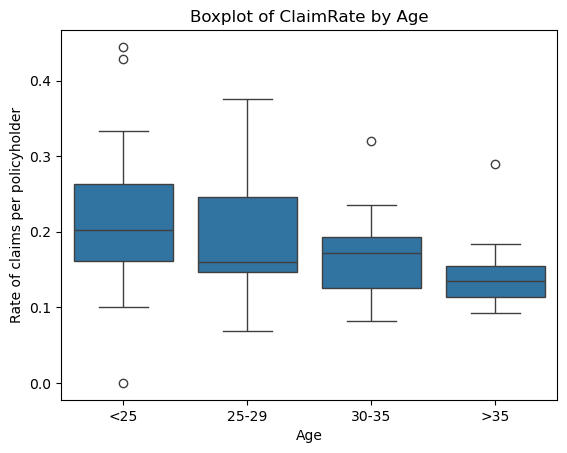

In [7]:
sns.boxplot(x=Insurance["Age"], y=Insurance["ClaimRate"], data=Insurance)
plt.ylabel("Rate of claims per policyholder")
plt.title("Boxplot of ClaimRate by Age")
plt.show()

There are small differences in the means of the rate of claims per policy holders with respect to the district but there are large differences with respect to the type of car and the age group. 

**Note:** The "Age" boxplot for the "<25" group may appear different from R because Seaborn (and Matplotlib’s boxplot) does not extend the whiskers all the way to the lower whisker value you calculated. Instead, the whiskers stop at the smallest data point within the specified range that is not considered an outlier. This means the lower whisker in the Python boxplot will extend to the minimum value that is greater than or equal to the calculated lower whisker, rather than the exact lower whisker value.

## Poisson Regression

The Python command is again sm.GLM also used in logistic regression although for this example we use family=poisson. This example illustrates the need to consider what is called exposure. Poisson regression is also appropriate for rate data where the rate is a count of the events occurring for a particular unit of observations. Which means that a rate is the count of events divided by the number of units. 

In this example, the response variable consists of two components. The number of claims and the number of policy holders. The number of claims is the number of events, and the number of policy holders represents the number of units. To get the rate of claims per policy holder, we take the ratio between the number of claims and the number of policy holders. Thus, we model the rate of claims per policy holder. 

In Poisson regression, this is handled using an offset, where the exposure variable is added in the linear combination of the predicting variables, but with the coefficient for log of exposure is constrained to one. That is, in the equation for the log of the expectation of the response data, we're adding another term, which is log of exposure. The offset option in the sm.GLM() command allows us to include log of exposure in the model without estimating a regression coefficient for the exposure. In this example the number of policy holders is the exposure thus the offset is equal to the log of the number of policy holders. Please do remember to account for this offset when the number of units is different across the observed responses as in this example. 

The python implementation is below.

In [8]:
Insurance_copy = Insurance.copy()

# Set the same baseline for each predictor as in R
Insurance_copy["District"] = Insurance_copy["District"].astype("category").cat.rename_categories(["1", "2","3","4"])
Insurance_copy["Group"] = pd.Categorical(Insurance_copy["Group"], categories=["<1l", "1-1.5l", "1.5-2l", ">2l"], ordered=True)
Insurance_copy["Age"] = pd.Categorical(Insurance_copy["Age"], categories=["<25", "25-29", "30-35", ">35"], ordered=True)

# One-hot encode the categorical variables to dummy variables
X = pd.get_dummies(Insurance_copy[["District", "Group", "Age"]], drop_first=True)

# Add intercept
X = sm.add_constant(X)

# Set offset (log of Holders)
offset = np.log(Insurance_copy["Holders"])
X = X.astype(float)

model = sm.GLM(Insurance_copy["Claims"], X, family=sm.families.Poisson(), offset=offset).fit()

print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 Claims   No. Observations:                   64
Model:                            GLM   Df Residuals:                       54
Model Family:                 Poisson   Df Model:                            9
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -184.37
Date:                Thu, 22 May 2025   Deviance:                       51.420
Time:                        22:56:45   Pearson chi2:                     48.6
No. Iterations:                     6   Pseudo R-squ. (CS):             0.9443
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -1.8217      0.077    -23.724   

In [9]:
# Second option of Possion model
model1 = smf.glm(formula='Claims ~ Age + District + Group', data=Insurance_copy, family=sm.families.Poisson(), offset=offset).fit()
print(model1.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 Claims   No. Observations:                   64
Model:                            GLM   Df Residuals:                       54
Model Family:                 Poisson   Df Model:                            9
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -184.37
Date:                Thu, 22 May 2025   Deviance:                       51.420
Time:                        22:56:45   Pearson chi2:                     48.6
No. Iterations:                     6   Pseudo R-squ. (CS):             0.9443
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -1.8217      0.077    -


Above is the Python output for the model where the response variable is the rate of claims per policyholder. 
In this example, the baseline for the age of group is the young group up to 25 years old. When comparing the age group of 25-29 versus the baseline age group, the regression coefficient is negative and statistically significant. The ratio of the rate claims per policyholder for age group 25-29 versus 25 or younger is 0.826 because it is equal to the exponential of the beta for the corresponding dummy variable, which is -0.191, suggesting a statistically significantly lower rate of claims for those of age 25 to 29 versus the younger adults, given all other predicting variables fixed in the model. When comparing other age groups to the baseline group, the regression coefficients are again statistically significant and negative, thus the rates of claims are not similar for the 25 and younger policyholders versus those 25 and older.  

## Testing for Overall Regression

Let's also evaluate the overall regression. We compute the p-value of the test using the chi square distribution with 9 degrees of freedom.

In [10]:
null_deviance = model.null_deviance
model_deviance = model.deviance
df_model = model.df_model

# test statistic
test_statistic = null_deviance - model_deviance

# p-value
p_value = 1 - chi2.cdf(test_statistic, df_model)

print(f"Likelihood Ratio Test p-value: {p_value}")

Likelihood Ratio Test p-value: 0.0


The p-value for this test is approximately 0. Thus, the overall regression is statistically significant. 

## Testing for Subsets of Coefficients

Let's address the following question, *is the district of residence of policyholder  statistically significant given all other predicting variables in the model?* For this, we compare the reduced model with only age and group, versus the full model including also the dummy variables corresponding to the district predicting variable. 

For this test, we will use the wald test.  The Wald test is the test for subset of regression coefficients. The input consists of the estimated regression coefficients the beta hats and the variance covariance matrix of the estimated beta hats. We also need to specify the coefficients in the vector beta that need to be tested. The vector of regression coefficients includes the intercept, three dummy variables for the district variable, three dummy variables for the group of cars and three dummy variables for the age factor. 

Since the reduced model does not include the district variable, thus we discard all dummy variables corresponding to the district factor, this reduces to the regression model without these three dummy variables in the positions 2 to 4 in the vector of the regression coefficients. Thus, in the wald test, we need to specify the ‘Terms’ consisting of the indices in the vector of regression coefficients that need to be tested to be equal to zero in the null hypothesis, which are again in the positions 2 to 4. The output of this test is provided as on the slide.

In [11]:
from scipy.stats import chi2

coefficients = model.params
vcov_matrix = model.cov_params()

# Define the terms for which you want to perform the Wald test (e.g., coefficients 2:4)
terms = [1, 2, 3]

# Extract the relevant coefficients and the sub-matrix of the covariance matrix
beta = coefficients[terms]
vcov_submatrix = vcov_matrix.iloc[terms, terms]

# Calculate the Wald statistic (Wald statistic = beta' * inv(Sigma) * beta)
wald_stat = np.dot(np.dot(beta, np.linalg.inv(vcov_submatrix)), beta)

df = len(terms)
p_value = chi2.sf(wald_stat, df)

print(f"Wald Statistic: {wald_stat:4f}")
print(f"Degrees of Freedom: {df}")
print(f"P-Value: {p_value:4f}")

Wald Statistic: 14.634441
Degrees of Freedom: 3
P-Value: 0.002157


The p-value of the test is 0.002. Since the p-value is small, we reject the null hypothesis and thus conclude that the district predicting variable has explanatory power for the rate of claims per policyholder. 